In [13]:
#mounting to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [15]:
#upload dataset
df = pd.read_csv('/content/drive/MyDrive/Tesla_stock_data.csv')
print(df.shape)
print(df.head())

(3920, 6)
         Date     Close      High       Low      Open     Volume
0  2010-06-29  1.592667  1.666667  1.169333  1.266667  281494500
1  2010-06-30  1.588667  2.028000  1.553333  1.719333  257806500
2  2010-07-01  1.464000  1.728000  1.351333  1.666667  123282000
3  2010-07-02  1.280000  1.540000  1.247333  1.533333   77097000
4  2010-07-06  1.074000  1.333333  1.055333  1.333333  103003500


In [16]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
print('Date cleaned!')
print(df.dtypes)

Date cleaned!
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
Year               int32
Month              int32
dtype: object


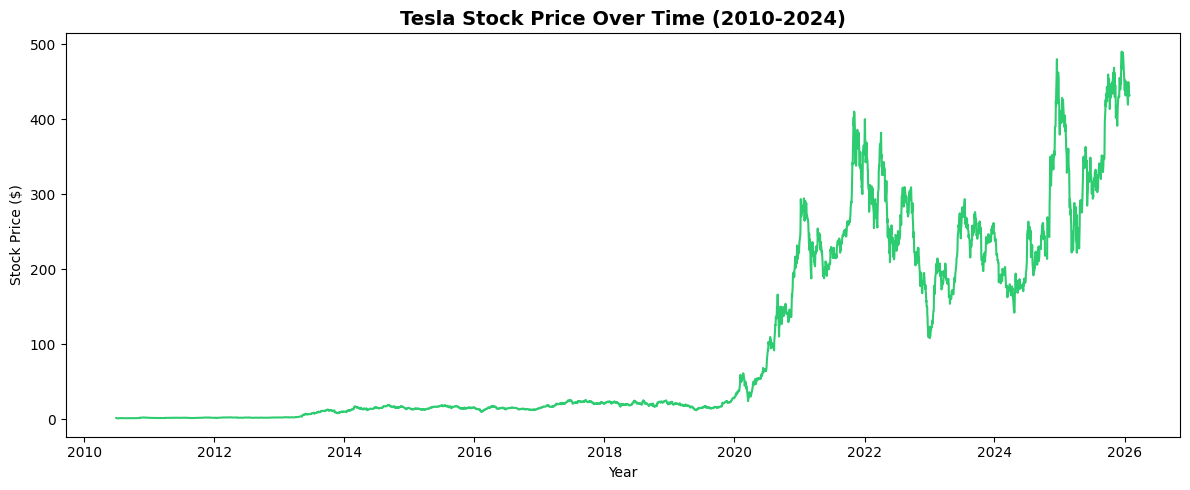

In [17]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], color='#2ecc71', linewidth=1.5)
plt.title('Tesla Stock Price Over Time (2010-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Stock Price ($)')
plt.tight_layout()
plt.savefig('chart1_price_over_time.png', dpi=150)
plt.show()

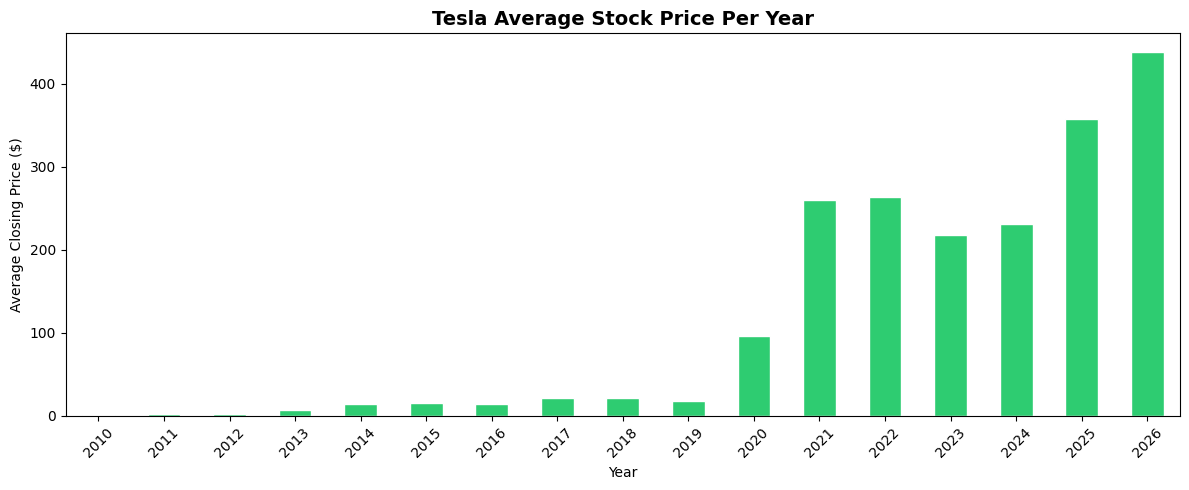

In [18]:
yearly_avg = df.groupby('Year')['Close'].mean()
plt.figure(figsize=(12,5))
yearly_avg.plot(kind='bar', color='#2ecc71', edgecolor='white')
plt.title('Tesla Average Stock Price Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Closing Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_yearly_average.png', dpi=150)
plt.show()

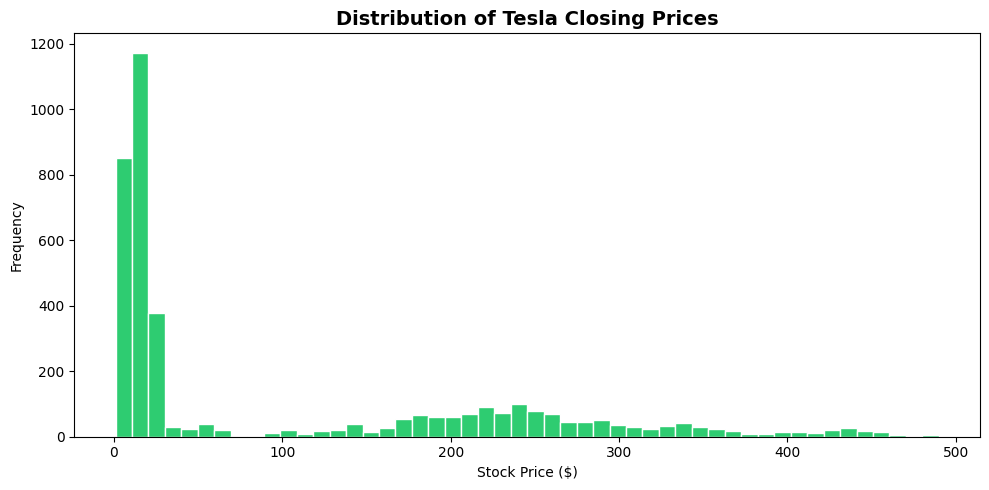

In [19]:
plt.figure(figsize=(10,5))
plt.hist(df['Close'], bins=50, color='#2ecc71', edgecolor='white')
plt.title('Distribution of Tesla Closing Prices', fontsize=14, fontweight='bold')
plt.xlabel('Stock Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('chart3_distribution.png', dpi=150)
plt.show()

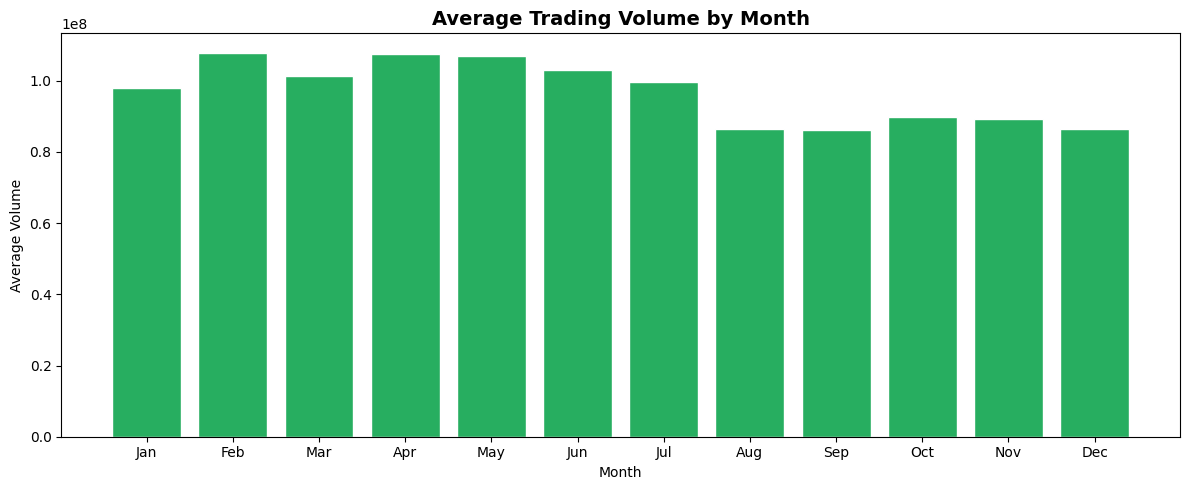

In [20]:
monthly_vol = df.groupby('Month')['Volume'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(12,5))
plt.bar(month_names, monthly_vol.values, color='#27ae60', edgecolor='white')
plt.title('Average Trading Volume by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.tight_layout()
plt.savefig('chart4_monthly_volume.png', dpi=150)
plt.show()

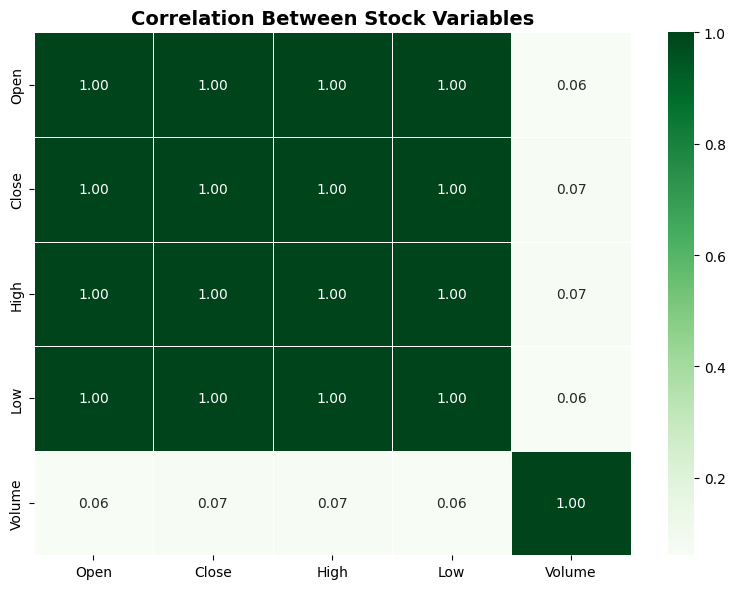

In [10]:
plt.figure(figsize=(8,6))
corr = df[['Open','Close','High','Low','Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens', linewidths=0.5)
plt.title('Correlation Between Stock Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150)
plt.show()

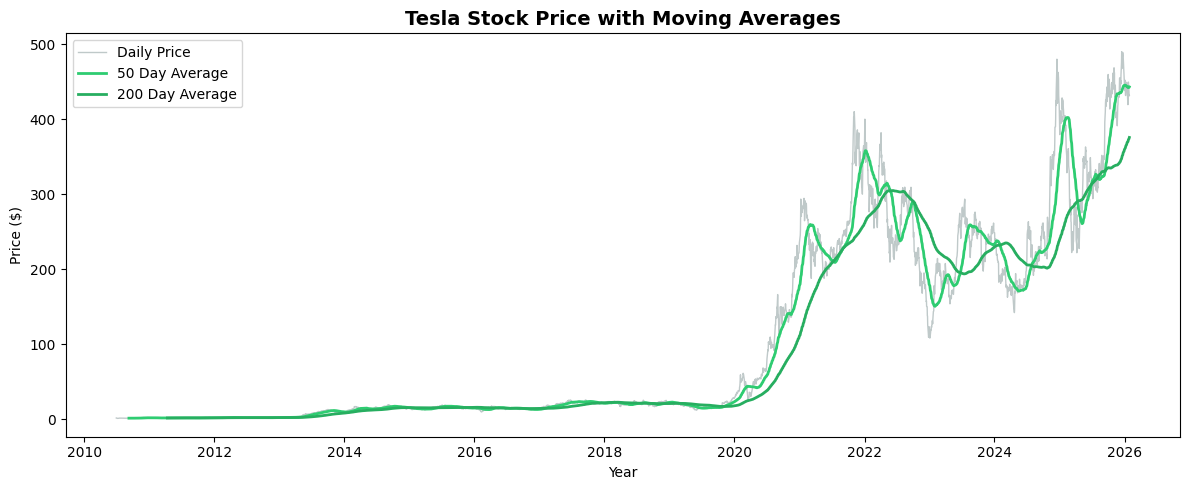

In [11]:
df['MA50'] = df['Close'].rolling(window=50).mean()
df['MA200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], color='#95a5a6', linewidth=1, label='Daily Price', alpha=0.6)
plt.plot(df['Date'], df['MA50'], color='#2ecc71', linewidth=2, label='50 Day Average')
plt.plot(df['Date'], df['MA200'], color='#27ae60', linewidth=2, label='200 Day Average')
plt.title('Tesla Stock Price with Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('chart6_moving_average.png', dpi=150)
plt.show()

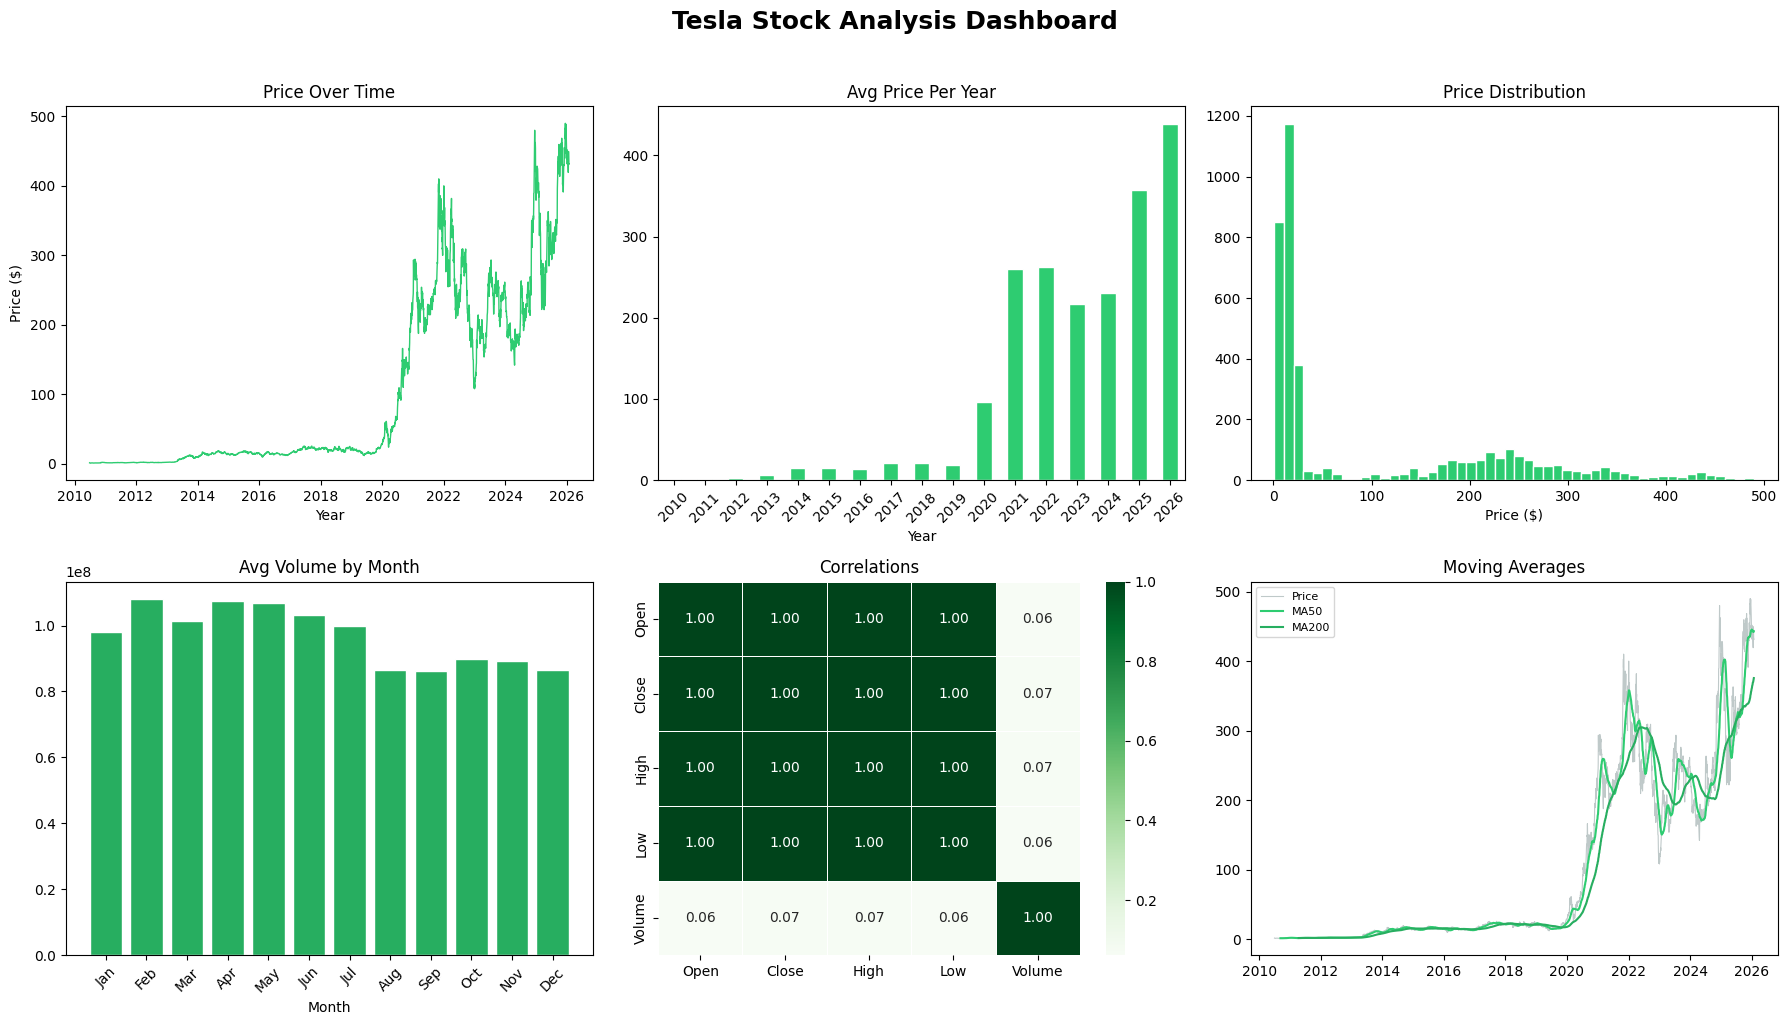

Dashboard saved!


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Tesla Stock Analysis Dashboard', fontsize=18, fontweight='bold', y=1.02)

# Chart 1 - Price over time
axes[0,0].plot(df['Date'], df['Close'], color='#2ecc71', linewidth=1)
axes[0,0].set_title('Price Over Time')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Price ($)')

# Chart 2 - Yearly average
yearly_avg.plot(kind='bar', ax=axes[0,1], color='#2ecc71', edgecolor='white')
axes[0,1].set_title('Avg Price Per Year')
axes[0,1].set_xlabel('Year')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 - Distribution
axes[0,2].hist(df['Close'], bins=50, color='#2ecc71', edgecolor='white')
axes[0,2].set_title('Price Distribution')
axes[0,2].set_xlabel('Price ($)')

# Chart 4 - Monthly volume
axes[1,0].bar(month_names, monthly_vol.values, color='#27ae60', edgecolor='white')
axes[1,0].set_title('Avg Volume by Month')
axes[1,0].set_xlabel('Month')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 5 - Heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Greens', ax=axes[1,1], linewidths=0.5)
axes[1,1].set_title('Correlations')

# Chart 6 - Moving averages
axes[1,2].plot(df['Date'], df['Close'], color='#95a5a6', linewidth=0.8, alpha=0.6, label='Price')
axes[1,2].plot(df['Date'], df['MA50'], color='#2ecc71', linewidth=1.5, label='MA50')
axes[1,2].plot(df['Date'], df['MA200'], color='#27ae60', linewidth=1.5, label='MA200')
axes[1,2].set_title('Moving Averages')
axes[1,2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('dashboard_tesla.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved!')